In [1]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library(stringr)

Attaching SeuratObject


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
drds <- "/DATA/User/liqian7/pienapple/24AS_fig_add/00DATA/04fn_data/04AS_ud/"
dout <- "/DATA/User/liqian7/pienapple/24AS_fig_add/04fig3/01layer_pseudobulk/01pseudobulk/"

In [ ]:
drds <- "/DATA/User/liqian7/pienapple/24AS_fig_add/00DATA/04fn_data/04AS_ud/"
dout <- "/DATA/User/liqian7/pienapple/24AS_fig_add/04fig3/01layer_pseudobulk/01pseudobulk/"
k=0
for(s in Sys.glob(file.path(drds,"*_uc.RDS"))){
    k=k+1
    key <- gsub("_uc.RDS","",basename(s))
    sp <- readRDS(paste0(drds,key,"_uc.RDS"))
    sp@meta.data$layer <- round(sp@meta.data$layer)
    n=0
    for(i in unique(sp@meta.data$layer)){
        n=n+1
        sp1 <- subset(sp,subset = layer==i)
        counts <- data.frame(rowSums(as.matrix(sp1@assays$RNA@counts)))
        colnames(counts) <- paste0(key,"_",i)
        m <- as.data.frame(paste0(key,"_",i))
        colnames(m) <- "sample"
        m$chip_id <- key
        m$layer <- i
        m$stage_ann <- unique(sp@meta.data$stage_ann)
        m$sample_filter <- unique(sp@meta.data$sample)
        m$stage_ann_peaks <- unique(sp@meta.data$stage_ann_peaks)
        m$level <- unique(sp@meta.data$level)
        m$ns_stage <- unique(sp@meta.data$ns_stage)
        m$ns_stage_peak <- unique(sp@meta.data$ns_stage_peak)
        m$as_stage <- unique(sp@meta.data$as_stage)
        m$adventitia <- unique(sp@meta.data$adventitia)
        m$stage_clinical <- unique(sp@meta.data$stage_clinical)
        rownames(m) <- m$sample
        if(n==1){
            counts1 <- counts
            m1 <- m
        }
        else{
            counts1 <- merge(counts1,counts,all = TRUE,by = 0)
            rownames(counts1) <- counts1$Row.names
            counts1 <- counts1[,-1]
            m1 <-rbind(m1,m)
        }
    }
    if(k==1){
        counts2 <- counts1
        m2 <- m1
    }
    else{
        counts2 <- merge(counts2,counts1,all = TRUE,by = 0)
        rownames(counts2) <- counts2$Row.names
        counts2 <- counts2[,-1]
        m2 <- rbind(m2,m1)
    }
    print(head(m2))
    print(head(counts2))
}

In [3]:
setwd("./01pseudobulk/")

In [77]:
setwd("./01pseudobulk/")
counts2[is.na(counts2)] <- 0
saveRDS(m2,"pseudobulk_meta.RDS")
saveRDS(counts2,"pseudobulk_counts2.RDS")

In [4]:
m2 <- readRDS("pseudobulk_meta.RDS")
counts2 <- readRDS("pseudobulk_counts2.RDS")

In [5]:
sp <- readRDS("pseudobulk_seurat.RDS")

In [79]:
sp <- CreateSeuratObject(counts = counts2,meta.data = m2)

In [80]:
saveRDS(sp,"pseudobulk_seurat.RDS")

In [56]:
setwd("./03fig3B_human/")

In [4]:
#####
sp <- readRDS("pseudobulk_seurat.RDS")

In [5]:
sp <- NormalizeData(sp)

In [7]:
mer <- merge(as.data.frame(t(as.data.frame(sp@assays$RNA@data))),sp@meta.data,all = TRUE,by = 0)
rownames(mer) <- mer$Row.names
mer <- mer[,-1]
mer$layer <-abs(mer$layer-100)
mer1 <- mer[which(mer$sample_filter!="filter"),]
head(mer1)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.1 GiB”


,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,⋯,layer,stage_ann,sample_filter,stage_ann_peaks,level,ns_stage,ns_stage_peak,as_stage,adventitia,stage_clinical
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A05872E5_1_1,0,0.3554620,0.3554620,1.484944,0,0,0.355462,0,0.0000000,0.0000000,⋯,99,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_10,0,0.0000000,0.0000000,1.656940,0,0,0.000000,0,0.2352324,0.0000000,⋯,90,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_100,0,0.3613166,0.3613166,2.018665,0,0,0.000000,0,0.3613166,0.0000000,⋯,0,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_11,0,0.0000000,0.0000000,1.762338,0,0,0.000000,0,0.0000000,0.0000000,⋯,89,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_12,0,0.2550586,0.0000000,1.501061,0,0,0.000000,0,0.0000000,0.2550586,⋯,88,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_13,0,0.0000000,0.0000000,1.953120,0,0,0.000000,0,0.0000000,0.3592044,⋯,87,stage3,save,stage3,good,stage1,stage2,stage2,none,late


In [8]:
mer1 <- mer[which(mer$sample_filter!="filter"),]
head(mer1)

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A2MP1,A3GALT2,⋯,layer,stage_ann,sample_filter,stage_ann_peaks,level,ns_stage,ns_stage_peak,as_stage,adventitia,stage_clinical
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A05872E5_1_1,0,0.3554620,0.3554620,1.484944,0,0,0.355462,0,0.0000000,0.0000000,⋯,99,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_10,0,0.0000000,0.0000000,1.656940,0,0,0.000000,0,0.2352324,0.0000000,⋯,90,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_100,0,0.3613166,0.3613166,2.018665,0,0,0.000000,0,0.3613166,0.0000000,⋯,0,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_11,0,0.0000000,0.0000000,1.762338,0,0,0.000000,0,0.0000000,0.0000000,⋯,89,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_12,0,0.2550586,0.0000000,1.501061,0,0,0.000000,0,0.0000000,0.2550586,⋯,88,stage3,save,stage3,good,stage1,stage2,stage2,none,late
A05872E5_1_13,0,0.0000000,0.0000000,1.953120,0,0,0.000000,0,0.0000000,0.3592044,⋯,87,stage3,save,stage3,good,stage1,stage2,stage2,none,late


In [ ]:
cols5 <- c('stage1'='#a7d3d4','stage2'='#009b9e','stage3'='#e4c1d9','stage4'='#c75dab')

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


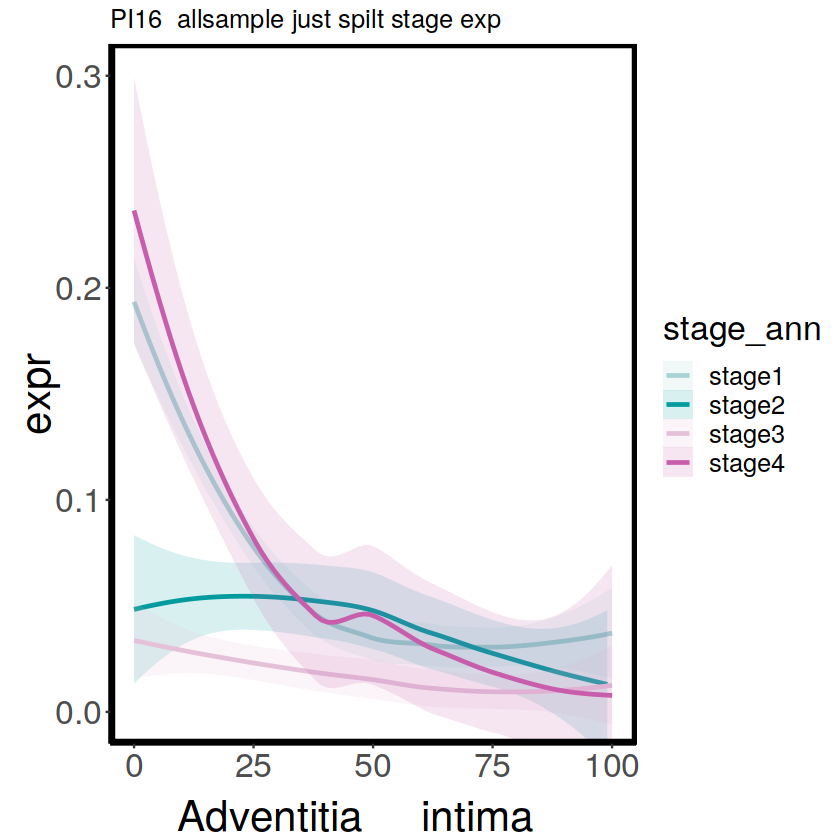

NULL

`geom_smooth()` using formula = 'y ~ x'


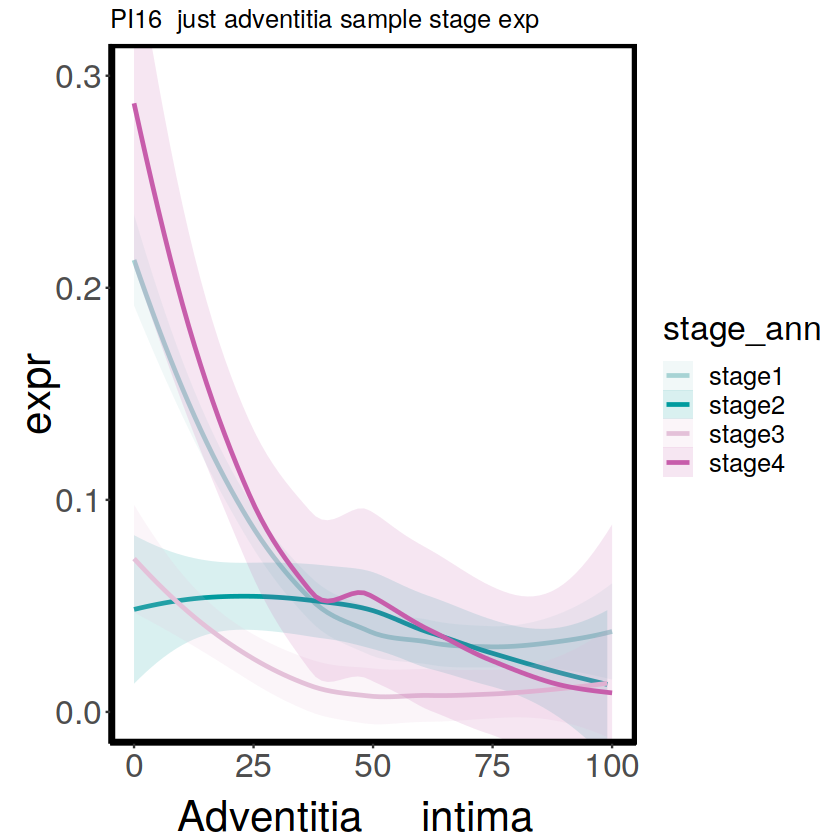

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


png 
  2

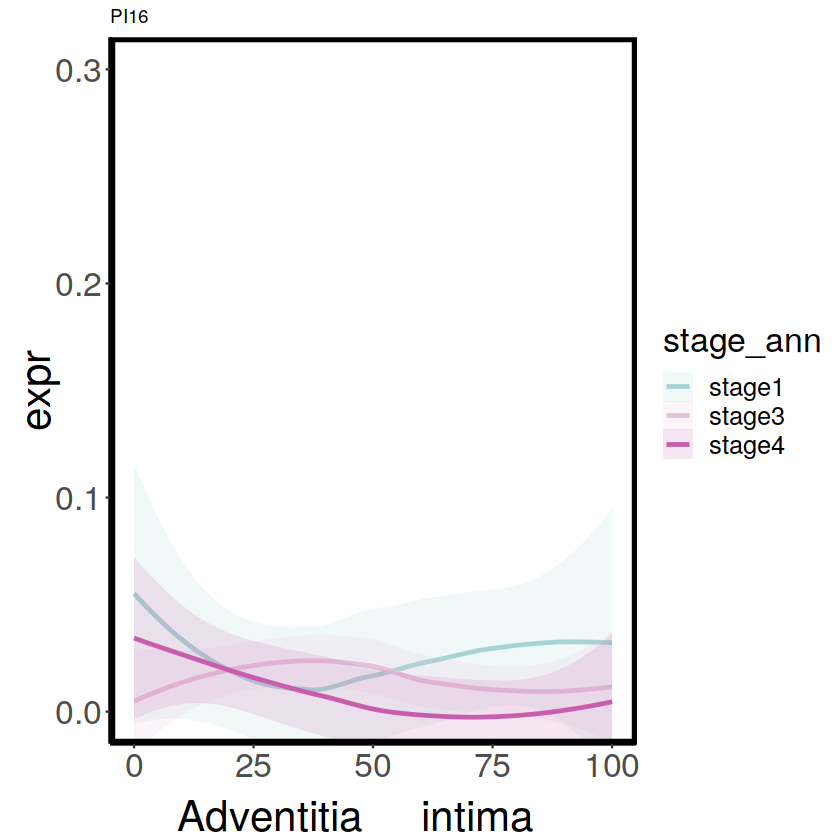

In [11]:
gene <- "PI16"
p1<- ggplot(mer1,aes(x=layer,y = get(gene),fill=stage_ann,color=stage_ann))+theme_classic ()+
labs(subtitle = gene)+geom_smooth(method = "loess",span=1,se = T,level=0.95,alpha=0.15)+scale_fill_manual(values =cols5)+scale_color_manual(values = cols5)+
labs(x="Adventitia     intima   ",y="expr")+theme_bw()+theme(panel.grid = element_blank())+
theme_classic()+theme(axis.text = element_text (size = 20))+
theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
theme(plot.title = element_text(size = 25, face = "bold"))+
theme(axis.line = element_line(color = "black",linewidth = 0.8))+
theme(legend.title = element_text(size=20),
      legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+coord_cartesian(ylim = c(0, 0.3))+
labs(subtitle = paste0(gene,"  allsample just spilt stage exp"))+theme(plot.subtitle = element_text(size = 15))
print(p1)
p2 <- ggplot(mer1[which(mer1$adventitia!="none"),],aes(x=layer,y = get(gene),fill=stage_ann,color=stage_ann))+theme_classic ()+
labs(subtitle = gene)+geom_smooth(method = "loess",span=1,se = T,level=0.95,alpha=0.15)+scale_fill_manual(values =cols5)+scale_color_manual(values = cols5)+
labs(x="Adventitia     intima   ",y="expr")+theme_bw()+theme(panel.grid = element_blank())+
theme_classic()+theme(axis.text = element_text (size = 20))+
theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
theme(plot.title = element_text(size = 25, face = "bold"))+
theme(axis.line = element_line(color = "black",linewidth = 0.8))+
theme(legend.title = element_text(size=20),
      legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+coord_cartesian(ylim = c(0, 0.3))+
labs(subtitle = paste0(gene,"  just adventitia sample stage exp"))+theme(plot.subtitle = element_text(size = 15))
print(p2)

p3 <- ggplot(mer1[which(mer1$adventitia=="none"),],aes(x=layer,y = get(gene),fill=stage_ann,color=stage_ann))+theme_classic ()+
labs(subtitle = gene)+geom_smooth(method = "loess",span=1,se = T,level=0.95,alpha=0.15)+scale_fill_manual(values =cols5)+scale_color_manual(values = cols5)+
labs(x="Adventitia     intima   ",y="expr")+theme_bw()+theme(panel.grid = element_blank())+
theme_classic()+theme(axis.text = element_text (size = 20))+
theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+
theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+
theme(plot.title = element_text(size = 25, face = "bold"))+
theme(axis.line = element_line(color = "black",linewidth = 0.8))+
theme(legend.title = element_text(size=20),
      legend.text = element_text(size=15))+
theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 2))+coord_cartesian(ylim = c(0, 0.3))
labs(subtitle = paste0(gene,"  just None adventitia sample stage exp"))+theme(plot.subtitle = element_text(size = 15))
print(p3)
pdf(paste0(gene,"_sample_tissue_stage.pdf"),width = 20,height = 6)
print(p1|p2|p3)
dev.off()